In [ ]:
from quspin.operators import hamiltonian  # Hamiltonians and operators
from quspin.basis import spin_basis_general  # spin basis constructor
import numpy as np  # general math functions
import matplotlib.pyplot as plt  # plotting library
from tqdm.notebook import tqdm  # progress bar
from joblib import Parallel, delayed  # for parallel computing

##### define model parameters #####
# T - drive period alpha - noise parameter
N = 1+12+2  # system size
J = 1.0
U1 = 10.0
U2 = 5.0
T = 300
Omega = 0.5 * np.pi / T 

# construct basis
basis = spin_basis_general(N)

Omega = 0.5 * np.pi / T   # drive frequency
# define ramping functions
def drive_1(t, Omega):
    if T <= t <= 2*T:
        return np.cos(Omega * t)**2
    else:
        return 1.0
def drive_2(t, Omega):
    if T <= t <= 2*T:
        return np.sin(Omega * t)**2
    else:
        return 0.0

def drive_other(t, Omega):
    if 0 <= t <= T:
        return np.sin(Omega * t)**2
    else:
        return 1.0

drive_args = [Omega]

# define site-coupling lists for operators
sxx = [[J/2, 1, 2], [J/2, 3, 4]]
sxx += [[J/2, 5, 6], [J/2, 7, 8], [J/2, 13, 14]]
sxx += [[J/2, 9, 10], [J/2, 11, 12]]
syy = [[J/2, 1, 2], [J/2, 3, 4]]
syy += [[J/2, 5, 6], [J/2, 7, 8], [J/2, 13, 14]]
syy += [[J/2, 9, 10], [J/2, 11, 12]]
szz_1 = [[U1, 1, 2], [U1, 3, 4]]
szz_1 += [[U1, 5, 6], [U1, 7, 8], [U1, 13, 14]]
szz_1 += [[U1, 9, 10], [U1, 11, 12]]
szz_2 = [[U2, 2, 3]]
szz_2 += [[U2, 6, 7]]
szz_2 += [[U2, 10, 11]]
J12 = [[U2, 0, 1, 5]]
J23 = [[U2, 0, 5, 9]]
Jo = [[U2, 8, 13]]

# static lists
static = [
    ["xx", sxx],
    ["yy", syy],
    ["zz", szz_1],
    ["zz", szz_2],
]
# dynamic lists
dynamic = [
    ["zzz", J12, drive_1, drive_args],
    ["xzz", J23, drive_2, drive_args],
    ["zz", Jo, drive_other, drive_args],
]
# build hamiltonian
no_check = dict(check_herm=False, check_pcon=False, check_symm=False)
H = hamiltonian(static, dynamic, basis=basis, dtype=np.complex128, **no_check)

# Time grid
times = np.linspace(0, 2*T, 10)

# Get the two lowest instantaneous eigenstates at t=0
E0, V0 = H.eigh(time=0.0)

# Use the two lowest states at t=0 as initial states
psi0_e = V0[:, 0]
psi0_o = V0[:, 1]

# Time evolve both states
psi_e_t = list(
    H.evolve(
        psi0_e, 0.0, times,
        solver_name="dop853",
        atol=1e-12, rtol=1e-10,
        iterate=True
    )
)

psi_o_t = list(
    H.evolve(
        psi0_o, 0.0, times,
        solver_name="dop853",
        atol=1e-12, rtol=1e-10,
        iterate=True
    )
)

# Compute the two instantaneous lowest eigenstates at each time
def instantaneous_two_states(t):
    E, V = H.eigh(time=t)
    return V[:, 0], V[:, 1]

gs_t = Parallel(n_jobs=8, verbose=10)(
    delayed(instantaneous_two_states)(t) for t in times
)

# Fidelity for the two branches
fidelity_e = np.array([
    np.abs(np.vdot(gs_t[i][0], psi_e_t[i]))**2
    for i in range(len(times))
])

fidelity_o = np.array([
    np.abs(np.vdot(gs_t[i][1], psi_o_t[i]))**2
    for i in range(len(times))
])

# Plot both fidelities
plt.style.use('aps.mplstyle')
fig, ax = plt.subplots()
ax.plot(times/T, fidelity_e, color='C0', linewidth=2, label=r'$F_e(t)$')
ax.plot(times/T, fidelity_o, color='C1', linewidth=2, label=r'$F_o(t)$')
ax.set_xlabel(r'$t/\tau$')
ax.set_ylabel(r'$F(t)$')
ax.set_xmargin(0)
ax.set_ylim(0, 1.02)
ax.grid(True, ls='--', alpha=0.4)
ax.legend(frameon=True)
plt.show()

### Adaptive spatial shift 

In [81]:
from quspin.operators import hamiltonian  # Hamiltonians and operators
from quspin.basis import spin_basis_general  # spin basis constructor
import numpy as np  # general math functions
import matplotlib.pyplot as plt  # plotting library
from tqdm.notebook import tqdm  # progress bar
from joblib import Parallel, delayed  # for parallel computing

##### define model parameters #####
# T - drive period alpha - noise parameter
N = 1+12  # system size
J = 1.0
U1 = 10.0
U2 = 5.0
T = 300
Omega = 0.5 * np.pi / T 

# construct basis
basis = spin_basis_general(N)

Omega = 0.5 * np.pi / T   # drive frequency
# define ramping functions
def drive_1(t, Omega):
    if 2*T <= t <= 3*T:
        return np.cos(Omega * (t-2*T) )**2
    else:
        return 1.0
def drive_2(t, Omega):
    if 2*T <= t <= 3*T:
        return np.sin(Omega * (t-2*T))**2
    else:
        return 0.0

def move_1(t, Omega):
    if 0 <= t <= T:
        return np.cos(Omega * t)**2
    else:
        return 0.0

def move_2(t, Omega):
    if 0 <= t <= T:
        return 0.0
    elif T <= t <= 2*T:
        return np.sin(Omega * (t-T))**2
    else:
        return 1.0

drive_args = [Omega]

# define site-coupling lists for operators
sxx = [[J/2, 1, 2], [J/2, 3, 4]]
sxx += [[J/2, 5, 6], [J/2, 7, 8], [J/2, 9, 10]]
sxx += [[J/2, 11, 12]]
syy = [[J/2, 1, 2], [J/2, 3, 4]]
syy += [[J/2, 5, 6], [J/2, 7, 8], [J/2, 9, 10]]
syy += [[J/2, 11, 12]]
szz_1 = [[U1, 1, 2], [U1, 3, 4]]
szz_1 += [[U1, 5, 6], [U1, 7, 8], [U1, 9, 10]]
szz_1 += [[U1, 11, 12]]
szz_2 = [[U2, 6, 7]]
J12 = [[U2, 0, 1, 5]]
J23 = [[U2, 0, 5, 11]]
J1 = [[U2, 2, 3]]
J2 = [[U2, 8, 9]]

# static lists
static = [
    ["xx", sxx],
    ["yy", syy],
    ["zz", szz_1],
    ["zz", szz_2],
]
# dynamic lists
dynamic = [
    ["zzz", J12, drive_1, drive_args],
    ["xzz", J23, drive_2, drive_args],
    ["zz", J1, move_1, drive_args],
    ["zz", J2, move_2, drive_args],
]
# build hamiltonian
no_check = dict(check_herm=False, check_pcon=False, check_symm=False)
H = hamiltonian(static, dynamic, basis=basis, dtype=np.complex128, **no_check)

In [15]:
# Time grid
times = np.linspace(0, 3*T, 50)

def eigvals_at_time(t):
    E = H.eigsh(time=t, k=8, which='SA', return_eigenvectors=False)
    return np.sort(E)

E_t = Parallel(n_jobs=8, verbose=10)(
    delayed(eigvals_at_time)(t) for t in times
)

[Parallel(n_jobs=8)]: Using backend LokyBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Done   2 tasks      | elapsed:    1.5s
[Parallel(n_jobs=8)]: Done   9 tasks      | elapsed:    1.8s
[Parallel(n_jobs=8)]: Done  16 tasks      | elapsed:    2.9s
[Parallel(n_jobs=8)]: Done  25 tasks      | elapsed:    3.6s
[Parallel(n_jobs=8)]: Done  34 tasks      | elapsed:    4.4s
[Parallel(n_jobs=8)]: Done  41 out of  50 | elapsed:    4.9s remaining:    1.0s
[Parallel(n_jobs=8)]: Done  47 out of  50 | elapsed:    5.0s remaining:    0.2s
[Parallel(n_jobs=8)]: Done  50 out of  50 | elapsed:    5.1s finished


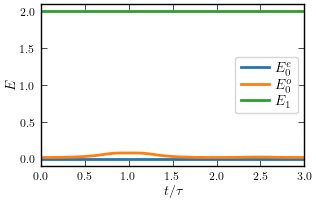

In [33]:
# plot the spectrum
plt.style.use('aps.mplstyle')
E_t = np.array(E_t) 
fig, ax = plt.subplots()
ax.plot(times/T, E_t[:, 0]-E_t[:, 0], linewidth=2, label = r'$E^e_0$')
ax.plot(times/T, E_t[:, 2]-E_t[:, 0], linewidth=2, label = r'$E^o_0$')
ax.plot(times/T, E_t[:, 4]-E_t[:, 0], linewidth=2, label = r'$E_1$')

ax.set_xlabel(r'$t/\tau$')
ax.set_ylabel(r'$E$')
ax.set_xmargin(0)
ax.legend(frameon=True)
plt.show()

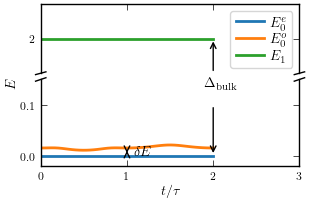

In [105]:
fig, (ax_top, ax_bottom) = plt.subplots(
    2, 1, sharex=True,
    gridspec_kw={'height_ratios': [1, 1.25], 'hspace': 0.08}
)

for axis in (ax_top, ax_bottom):
    axis.plot(times/T, E_t[:, 0] - E_t[:, 0], linewidth=2, label=r'$E^e_0$')
    axis.plot(times/T, E_t[:, 2] - E_t[:, 0], linewidth=2, label=r'$E^o_0$')
    axis.plot(times/T, E_t[:, 4] - E_t[:, 0], linewidth=2, label=r'$E_1$')

ax_bottom.set_ylim(-0.02, 0.15)
ax_top.set_ylim(1.95, 2.05)

ax_top.spines['bottom'].set_visible(False)
ax_bottom.spines['top'].set_visible(False)
ax_top.tick_params(bottom=False, labelbottom=False)

# Hide the spines between the two subplots.
ax_top.spines['bottom'].set_visible(False)
ax_bottom.spines['top'].set_visible(False)
ax_top.tick_params(axis='x', bottom=False, labelbottom=False)
ax_bottom.tick_params(axis='x', top=False, labeltop=False)

# Add diagonal lines to indicate the break in the y-axis.
d = 0.02
kwargs = dict(color='k', clip_on=False, linewidth=1)

ax_top.plot((-d, d), (-d, d),
            transform=ax_top.transAxes, **kwargs)
ax_top.plot((1 - d, 1 + d), (-d, d),
            transform=ax_top.transAxes, **kwargs)

ax_bottom.plot((-d, d), (1 - d, 1 + d),
               transform=ax_bottom.transAxes, **kwargs)
ax_bottom.plot((1 - d, 1 + d), (1 - d, 1 + d),
               transform=ax_bottom.transAxes, **kwargs)

fig.text(0.035, 0.5, r'$E$', rotation='vertical', va='center')
ax_bottom.set_xlabel(r'$t/\tau$')
ax_top.legend(frameon=True)
fig.subplots_adjust(left=0.14)

ax_top.set_ylim(1.95, 2.05)
ax_top.set_yticks([2.0])
ax_bottom.set_xlim(0, 3)
ax_bottom.set_xticks(np.arange(0, 3.1, 1.0))

# delta E
x_gap = 1
i_gap = np.argmin(np.abs(times / T - x_gap))

y0 = E_t[i_gap, 0] - E_t[i_gap, 0]
y2 = E_t[i_gap, 2] - E_t[i_gap, 0]

ax_bottom.annotate(
    '',
    xy=(x_gap, y2),
    xytext=(x_gap, y0),
    arrowprops=dict(
        arrowstyle='<->',
        color='black',
        linewidth=1.0
    )
)

ax_bottom.text(
    x_gap + 0.08,
    (y0 + y2) / 2,
    r'$\delta E$',
    color='black',
    va='center'
)

# Delta_bulk
x_bulk = 2.0

ax_top.annotate(
    '',
    xy=(x_bulk, 2.00),
    xytext=(x_bulk, 1.95),
    arrowprops=dict(
        arrowstyle='->',
        color='black',
        linewidth=1.0
    )
)

ax_bottom.annotate(
    '',
    xy=(x_bulk, 0.00),
    xytext=(x_bulk, 0.10),
    arrowprops=dict(
        arrowstyle='->',
        color='black',
        linewidth=1.0
    )
)

fig.text(
    0.62, 0.50,
    r'$\Delta_{\mathrm{bulk}}$',
    color='black',
    va='center',
    ha='left'
)

plt.show()

In [82]:
times = np.linspace(0, 3*T, 50)
# Compute the two instantaneous lowest eigenstates at each time
def instantaneous_two_states(t):
    E, V = H.eigh(time=t)
    return V[:, 0], V[:, 2]

gs_t = Parallel(n_jobs=8, verbose=10)(
    delayed(instantaneous_two_states)(t) for t in times
)  

# Use the two lowest states at t=0 as initial states
psi0_e, psi0_o = gs_t[0]

# Time evolve both states
psi_e_t = list(
    H.evolve(
        psi0_e, 0.0, times,
        solver_name="dop853",
        atol=1e-12, rtol=1e-10,
        iterate=True
    )
)

psi_o_t = list(
    H.evolve(
        psi0_o, 0.0, times,
        solver_name="dop853",
        atol=1e-12, rtol=1e-10,
        iterate=True
    )
)

[Parallel(n_jobs=8)]: Using backend LokyBackend with 8 concurrent workers.


MemoryError: Unable to allocate 1.00 GiB for an array with shape (8192, 8192) and data type complex128

In [ ]:
# Fidelity for the two branches
fidelity_e = np.array([
    np.abs(np.vdot(gs_t[i][0], psi_e_t[i]))**2
    for i in range(len(times))
])

fidelity_o = np.array([
    np.abs(np.vdot(gs_t[i][1], psi_o_t[i]))**2
    for i in range(len(times))
])

fidelity_e = np.abs(fidelity_e - 1/2)+1/2
fidelity_o = np.abs(fidelity_o - 1/2)+1/2

# fidelity_e[-1] = 1.0

# Plot both fidelities
plt.style.use('aps.mplstyle')
fig, ax = plt.subplots()
ax.plot(times/T, fidelity_e, color='C0', linewidth=2, label=r'$F_e(t)$')
ax.plot(times/T, fidelity_o, color='C1', linewidth=2, label=r'$F_o(t)$')
ax.set_xlabel(r'$t/\tau$')
ax.set_ylabel(r'$F(t)$')
ax.set_xmargin(0)
ax.set_ylim(0, 1.02)
ax.legend(frameon=True)
plt.savefig('figures/fig4c.eps', dpi=300, bbox_inches='tight')
plt.show()

IndexError: list index out of range

### same time

In [6]:
from quspin.operators import hamiltonian  # Hamiltonians and operators
from quspin.basis import spin_basis_general  # spin basis constructor
import numpy as np  # general math functions
import matplotlib.pyplot as plt  # plotting library
from tqdm.notebook import tqdm  # progress bar
from joblib import Parallel, delayed  # for parallel computing

##### define model parameters #####
# T - drive period alpha - noise parameter
N = 1+12  # system size
J = 1.0
U1 = 10.0
U2 = 5.0
T = 300
Omega = 0.5 * np.pi / T 

# construct basis
basis = spin_basis_general(N)

Omega = 0.5 * np.pi / T   # drive frequency
# define ramping functions
def drive_1(t, Omega):
    if T <= t <= 2*T:
        return np.cos(Omega * (t-T) )**2
    else:
        return 1.0
def drive_2(t, Omega):
    if T <= t <= 2*T:
        return np.sin(Omega * (t-T))**2
    else:
        return 0.0

def move_1(t, Omega):
    if 0 <= t <= T:
        return np.cos(Omega * t)**2
    else:
        return 0.0

def move_2(t, Omega):
    if 0 <= t <= T:
        return np.sin(Omega * t)**2
    else:
        return 1.0

drive_args = [Omega]

# define site-coupling lists for operators
sxx = [[J/2, 1, 2], [J/2, 3, 4]]
sxx += [[J/2, 5, 6], [J/2, 7, 8], [J/2, 9, 10]]
sxx += [[J/2, 11, 12]]
syy = [[J/2, 1, 2], [J/2, 3, 4]]
syy += [[J/2, 5, 6], [J/2, 7, 8], [J/2, 9, 10]]
syy += [[J/2, 11, 12]]
szz_1 = [[U1, 1, 2], [U1, 3, 4]]
szz_1 += [[U1, 5, 6], [U1, 7, 8], [U1, 9, 10]]
szz_1 += [[U1, 11, 12]]
szz_2 = [[U2, 6, 7]]
J12 = [[U2, 0, 1, 5]]
J23 = [[U2, 0, 5, 11]]
J1 = [[U2, 2, 3]]
J2 = [[U2, 8, 9]]

# static lists
static = [
    ["xx", sxx],
    ["yy", syy],
    ["zz", szz_1],
    ["zz", szz_2],
]
# dynamic lists
dynamic = [
    ["zzz", J12, drive_1, drive_args],
    ["xzz", J23, drive_2, drive_args],
    ["zz", J1, move_1, drive_args],
    ["zz", J2, move_2, drive_args],
]
# build hamiltonian
no_check = dict(check_herm=False, check_pcon=False, check_symm=False)
H = hamiltonian(static, dynamic, basis=basis, dtype=np.complex128, **no_check)

In [7]:
# Time grid
times = np.linspace(0, 2*T, 50)

def eigvals_at_time(t):
    E = H.eigsh(time=t, k=8, which='SA', return_eigenvectors=False)
    return np.sort(E)

E_t = Parallel(n_jobs=8, verbose=10)(
    delayed(eigvals_at_time)(t) for t in times
)

[Parallel(n_jobs=8)]: Using backend LokyBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Done   2 tasks      | elapsed:    1.9s
[Parallel(n_jobs=8)]: Done   9 tasks      | elapsed:    2.2s
[Parallel(n_jobs=8)]: Done  16 tasks      | elapsed:    2.6s
[Parallel(n_jobs=8)]: Done  25 tasks      | elapsed:    3.4s
[Parallel(n_jobs=8)]: Done  34 tasks      | elapsed:    3.9s
[Parallel(n_jobs=8)]: Done  41 out of  50 | elapsed:    4.2s remaining:    0.8s
[Parallel(n_jobs=8)]: Done  47 out of  50 | elapsed:    4.4s remaining:    0.2s
[Parallel(n_jobs=8)]: Done  50 out of  50 | elapsed:    4.4s finished


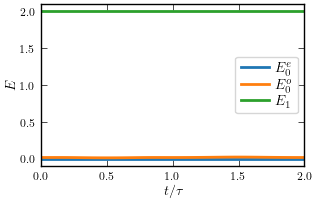

In [8]:
# plot the spectrum
plt.style.use('aps.mplstyle')
E_t = np.array(E_t) 
fig, ax = plt.subplots()
ax.plot(times/T, E_t[:, 0]-E_t[:, 0], linewidth=2, label = r'$E^e_0$')
ax.plot(times/T, E_t[:, 2]-E_t[:, 0], linewidth=2, label = r'$E^o_0$')
ax.plot(times/T, E_t[:, 4]-E_t[:, 0], linewidth=2, label = r'$E_1$')

ax.set_xlabel(r'$t/\tau$')
ax.set_ylabel(r'$E$')
ax.set_xmargin(0)
ax.legend(frameon=True)
plt.show()

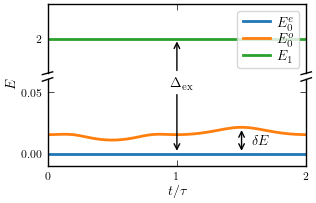

In [9]:
fig, (ax_top, ax_bottom) = plt.subplots(
    2, 1, sharex=True,
    gridspec_kw={'height_ratios': [1, 1.25], 'hspace': 0.08}
)

for axis in (ax_top, ax_bottom):
    axis.plot(times/T, E_t[:, 0] - E_t[:, 0], linewidth=2, label=r'$E^e_0$')
    axis.plot(times/T, E_t[:, 2] - E_t[:, 0], linewidth=2, label=r'$E^o_0$')
    axis.plot(times/T, E_t[:, 4] - E_t[:, 0], linewidth=2, label=r'$E_1$')

ax_bottom.set_ylim(-0.01, 0.06)
ax_top.set_ylim(1.95, 2.05)

ax_top.spines['bottom'].set_visible(False)
ax_bottom.spines['top'].set_visible(False)
ax_top.tick_params(bottom=False, labelbottom=False)

# Hide the spines between the two subplots.
ax_top.spines['bottom'].set_visible(False)
ax_bottom.spines['top'].set_visible(False)
ax_top.tick_params(axis='x', bottom=False, labelbottom=False)
ax_bottom.tick_params(axis='x', top=False, labeltop=False)

# Add diagonal lines to indicate the break in the y-axis.
d = 0.02
kwargs = dict(color='k', clip_on=False, linewidth=1)

ax_top.plot((-d, d), (-d, d),
            transform=ax_top.transAxes, **kwargs)
ax_top.plot((1 - d, 1 + d), (-d, d),
            transform=ax_top.transAxes, **kwargs)

ax_bottom.plot((-d, d), (1 - d, 1 + d),
               transform=ax_bottom.transAxes, **kwargs)
ax_bottom.plot((1 - d, 1 + d), (1 - d, 1 + d),
               transform=ax_bottom.transAxes, **kwargs)

fig.text(0.015, 0.5, r'$E$', rotation='vertical', va='center')
ax_bottom.set_xlabel(r'$t/\tau$')
ax_top.legend(frameon=True)
fig.subplots_adjust(left=0.14)

ax_top.set_ylim(1.95, 2.05)
ax_top.set_yticks([2.0])
ax_bottom.set_ylim(-0.01, 0.06)
ax_bottom.set_yticks([0.0, 0.05])
ax_bottom.set_xlim(0, 2)
ax_bottom.set_xticks(np.arange(0, 2.1, 1.0))

# delta E
x_gap = 1.5
i_gap = np.argmin(np.abs(times / T - x_gap))

y0 = E_t[i_gap, 0] - E_t[i_gap, 0]
y2 = E_t[i_gap, 2] - E_t[i_gap, 0]

ax_bottom.annotate(
    '',
    xy=(x_gap, y2),
    xytext=(x_gap, y0),
    arrowprops=dict(
        arrowstyle='<->',
        color='black',
        linewidth=1.0
    )
)

ax_bottom.text(
    x_gap + 0.08,
    (y0 + y2) / 2,
    r'$\delta E$',
    color='black',
    va='center'
)

# Delta_bulk
x_bulk = 1.0

ax_top.annotate(
    '',
    xy=(x_bulk, 2.00),
    xytext=(x_bulk, 1.95),
    arrowprops=dict(
        arrowstyle='->',
        color='black',
        linewidth=1.0
    )
)

ax_bottom.annotate(
    '',
    xy=(x_bulk, 0.00),
    xytext=(x_bulk, 0.05),
    arrowprops=dict(
        arrowstyle='->',
        color='black',
        linewidth=1.0
    )
)

fig.text(
    0.50, 0.50,
    r'$\Delta_{\mathrm{ex}}$',
    color='black',
    va='center',
    ha='left'
)

plt.savefig('figures/fig4b.pdf', dpi=300, bbox_inches='tight', facecolor='white')

plt.show()

In [10]:
times = np.linspace(0, 2*T, 20)
# Compute the two instantaneous lowest eigenstates at each time
def instantaneous_two_states(t):
    E, V = H.eigh(time=t)
    return V[:, 0], V[:, 2]

gs_t = Parallel(n_jobs=8, verbose=10)(
    delayed(instantaneous_two_states)(t) for t in times
)  

# Use the two lowest states at t=0 as initial states
psi0_e, psi0_o = gs_t[0]

# Time evolve both states
psi_e_t = list(
    H.evolve(
        psi0_e, 0.0, times,
        solver_name="dop853",
        atol=1e-12, rtol=1e-10,
        iterate=True
    )
)

psi_o_t = list(
    H.evolve(
        psi0_o, 0.0, times,
        solver_name="dop853",
        atol=1e-12, rtol=1e-10,
        iterate=True
    )
)

[Parallel(n_jobs=8)]: Using backend LokyBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Done   2 tasks      | elapsed: 18.9min
[Parallel(n_jobs=8)]: Done   8 out of  20 | elapsed: 19.1min remaining: 28.7min
[Parallel(n_jobs=8)]: Done  11 out of  20 | elapsed: 37.5min remaining: 30.7min
[Parallel(n_jobs=8)]: Done  14 out of  20 | elapsed: 41.0min remaining: 17.6min
[Parallel(n_jobs=8)]: Done  17 out of  20 | elapsed: 48.0min remaining:  8.5min
[Parallel(n_jobs=8)]: Done  20 out of  20 | elapsed: 48.7min finished
